# starting a fresh

We need to wrap our heads around what we have and make some notes on what we have learned so far...

## hitherto

We have reviewed the code in `Summer-code-compilation.ipynb` as well as reviewed the code that Allison used. We are trying to solve this problem about the code not replicating what Milan had. 

## herein

I want to compile things in a way that make the most sense to me, but that requires figuring out all of the options that we have and testing things, so that is what this is for.

## hence

it seems like the different input files of n and k are giving us different plots. this is something that we need to investigate. it is possible that the Fresnell data that joe uses is a different concentration of O and that is all the difference, but we need some confirmation on that

### ideas:

1. plot Milan's data here in python just so that we have a quick reference for it.
2. we need a faster zeroing method on the y axis so that we can make comparisons more quickly
3. 
4. 

In [123]:
%matplotlib widget 
#from ipywidgets import interact#, interactive, fixed, interact_manual
#import ipywidgets as widgets
#from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# import files and set up major parameters

the files we are importing are index of refraction and absorption values for our material which are a function of wavenumber (and therefore wavelength)

In [124]:
#1: Here is were you upload your excel file. The path depends on your specific computer. to upload a .csv change to pd.read_csv
#df = pd.read_excel("./Fresnell.xlsx")   

df = pd.read_excel("./Herguedas-SiOx-interpolated_2.xlsx", sheet_name='1.25', nrows=801) # nrows avoids extraneous data at the end of each sheet

#2: This puts Excel columns into arrays. Excel Columns must be set up using these exact names (wave_numbers, n0,n1,n2,k0,k1,k2) for python to read correctly.  
wave_numbers = df["wave_numbers"].values
n0_array = df["n0"].values
k0_array = df["k0"].values
n1_array = df["n1"].values
k1_array = df["k1"].values
n2_array = df["n2"].values
k2_array = df["k2"].values 

d = 1.65e-8 # always measured in cm -- 1e-8 cm is 1 angstrom; 10e-8 cm is 1 nanometer 
th0 = 80 # measured in degrees from the normal

# setting up other columns that can be helpful
df['wavelength'] = 1/df['wave_numbers']
df['d'] = d*np.ones(len(df))
df['th0'] = th0*np.ones(len(df))

# starter functions

In [125]:
#3: Basic functions defined for use
def cos(th):
    return np.cos(th*np.pi/180) 
def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2)) 
def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi 
def sin(th):
    return np.sin(th*np.pi/180) 

mu0 = 4*np.pi*10**-7

#4: Returns transmitted angle from incident angle. It gives you theta t from theta i. 
def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))

# basic functions

This is the essence of the transfer matrix stuff at least in the way that Joe originally composed it. This is something that I want to change at some point but it is fine for now.

In [126]:
#5: General form of fresnel coefficients for s polarized light (perpindicular electric field) 
def r_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(((ni+1j*ki)/mui*cos_thi-(nt+1j*kt)/mut*cos_tht)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht)) 
def t_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)  
    return((2*(ni+1j*ki)/mui*cos_thi)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

#6: General form of fresnel coefficients for p polarized light (parrallel electric field)  
def r_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((-(nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))
def t_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((2*(ni+1j*ki)/mui*cos_thi)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))  


#7: transmission matrix for P poloarized light. It relates the electric field on both sides of an interface. 
def D_p(ni, nt, ki, kt, thi, mui=mu0, mut=mu0):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((1/t_p(ni, nt, ki, kt, thi, mui, mut))*(np.array([[1,r_p(ni, nt, ki, kt, thi, mui, mut)],
                                                             [r_p(ni, nt, ki, kt, thi, mui, mut),1]])))  

#8: transmission matrix for S poloarized light. It relates the electric field on both sides of an interface. 
def D_s(ni, nt, ki, kt, thi, mui=mu0, mut=mu0):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((1/t_s(ni, nt, ki, kt, thi, mui, mut))*(np.array([[1,r_s(ni, nt, ki, kt, thi, mui, mut)],
                                                             [r_s(ni, nt, ki, kt, thi, mui, mut),1]])))  


#9: propagation matrix that relates electric field on both ends of the same medium. This is independant of polarazation.
def P(ni, nt, ki, kt, thi, d, wavelength):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(np.array([[np.exp(1j*2*np.pi*d*(nt+1j*kt)*cos_tht/wavelength),0],
                     [0,np.exp(-1j*2*np.pi*d*(nt+1j*kt)*cos_tht/wavelength)]]))


#10: the total fresnell coefficients. Used to relate to total amount of electric field transmitted or reflected in relation to incident electric field. 
# This is currently simulating a two interface system. More can easily be added but updates will need to be made to graphing code and exell file import code. 
def t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui, mut) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui, mut) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    return(1/M_11)  
def t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui, mut) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui, mut) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0]
    return(1/M_11)   
def r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui, mut) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui, mut) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    M_21 = M[1, 0]
    return(M_21/M_11) 
def r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui, mut) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui, mut) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0] 
    M_21 = M[1, 0]
    return(M_21/M_11)

def Fresnell_rtot(polarization, i):
    n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
    k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]
    wavelength = 1 / wave_numbers[i] # wave_number is in cm^-1 so this makes wavelength in cm which means that d needs to be in cm
    if polarization == 'p':
        return r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)#, t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)
    elif polarization=='s':
        return r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)#, t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)  
    else:
        print('you did not give a correct polarization -- enter s or p')


In [127]:


# df['rtot'] = r_p_tot(df['n0'], df['n1'], df['n2'], df['k0'], df['k1'], df['k2'], df['d'], df['th0'], df['wavelength'])
df['rtot'] = np.zeros(len(df), dtype=np.complex128)
#df['ttot'] = np.zeros(len(df), dtype=np.complex128)

#df['cos_theta_0'] = cos(df['th0'])
#df['theta_1'] = snells(df['n0'], df['n1'], df['k0'], df['k1'], df['th0'])
#df['theta_2'] = snells(df['n1'], df['n2'], df['k1'], df['k2'], df['theta_1'])
#df['cos_theta_2'] = cos(df['theta_2'])

for i in df.index:
    df.loc[i,'rtot'] = r_p_tot(df['n0'][i], df['n1'][i], df['n2'][i], df['k0'][i], df['k1'][i], df['k2'][i], df['d'][i], df['th0'][i], df['wavelength'][i])
    # df.loc[i,'ttot'] = t_p_tot(df['n0'][i], df['n1'][i], df['n2'][i], df['k0'][i], df['k1'][i], df['k2'][i], df['d'][i], df['th0'][i], df['wavelength'][i])

df['R'] = df['rtot']*np.conjugate(df['rtot']) # np.abs(df['rtot'])**2
# df['T'] = np.real((df['n2'] * df['cos_theta_2']) / (df['n0'] * df['cos_theta_0'])) * np.abs(df['ttot']) ** 2
df['A'] = 1 - df['R'] # - df['T']
baseline = np.log10(1/df['A'][0])
df['absorbance'] = -np.log10(df['A']) - baseline


/home/jupyter-ehreming/.local/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jupyter-ehreming/.local/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Absorbance')

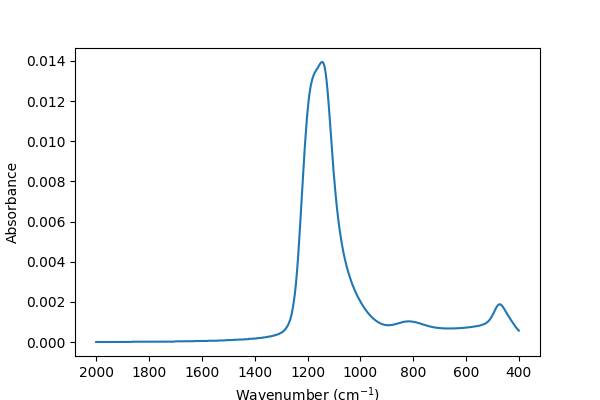

In [128]:
plt.close('all')

fig0 = plt.figure(figsize=(6, 4))
ax0 = fig0.subplots()
ax0.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax0.invert_xaxis()
#ax0.set_ylim(-1,2)
ax0.plot(df['wave_numbers'], df['absorbance'], label='Absorbance') 
ax0.set_ylabel('Absorbance') 

In [84]:
df.to_excel('test2.xlsx')

In [76]:
np.conjugate(df['rtot'])

0     -0.961496+0.149664j
1     -0.961494+0.149676j
2     -0.961490+0.149701j
3     -0.961487+0.149723j
4     -0.961485+0.149732j
              ...        
796   -0.960655+0.157091j
797   -0.960632+0.157144j
798   -0.960611+0.157196j
799   -0.960592+0.157249j
800   -0.960574+0.157301j
Name: rtot, Length: 801, dtype: complex128